Import needed libraries

In [23]:
import torch
import numpy as np
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from scipy.stats import mode
import seaborn as sb
from sklearn.manifold import TSNE
from scipy.special import comb
import math 


Setting HyperParameters

In [2]:
learning_rate = 0.001
num_of_epoch = 30
batch_size = 64

Reading and normalizing fashionMNIST data

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train=iter (train_loader)
[images , lablas] = next(train)
original_shape = images.shape
print(images.shape)

torch.Size([64, 1, 28, 28])


Creating AutoEncoder class

In [4]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super(AutoEncoder,self).__init__()
        self.activation = nn.ReLU()
        self.l1 = nn.Linear(784 , 300)
        self.l2 = nn.Linear(300 , 100)
        self.l3 = nn.Linear(100 , 10)
        self.l4 = nn.Linear(10 , 100)
        self.l5 = nn.Linear(100 , 300)
        self.l6 = nn.Linear(300 , 784)

    def forward (self , x):
        out = F.relu(self.l1(x))
        out = F.relu(self.l2(out))
        out = F.relu(self.l3(out))
        out = F.relu(self.l4(out))
        out = F.relu(self.l5(out))
        out = F.sigmoid(self.l6(out))
        return out
    
    def Encode(self,x):
        out = F.relu(self.l1(x))
        out = F.relu(self.l2(out))
        out = F.relu(self.l3(out))
        return out
    


Creating AutoEncoder object and setting loss and optimizer

In [30]:
model = AutoEncoder()
loss = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

Training time :D

In [31]:
train_loss = []
test_loss = []
for epoch in range(num_of_epoch):
    l0=0
    for i , (images , lables) in enumerate (train_loader):
        flattened = images.view(images.size(0), -1)
        outputs=model(flattened)

        Loss=loss(outputs , flattened)


        optimizer.zero_grad()

        Loss.backward()
        optimizer.step()
        l0 +=Loss
    train_loss.append(l0)
    
    print (f'in epoch {epoch+1}/{num_of_epoch} , loss is {l0:.4f}')

    with torch.no_grad():
        test = iter(test_loader)
        l1 = 0
        for ـ , (images , lables) in enumerate(test):
            flattened = images.view(images.size(0), -1)
            outputs=model(flattened)
            l1 +=loss(outputs , flattened)
        test_loss.append(l1)
    torch.save(model.state_dict() , './Models/AutoEncoder10.wght' )


    

in epoch 1/30 , loss is 31.6849
in epoch 2/30 , loss is 19.3532
in epoch 3/30 , loss is 18.2388
in epoch 4/30 , loss is 17.6034
in epoch 5/30 , loss is 17.1708
in epoch 6/30 , loss is 16.8102
in epoch 7/30 , loss is 16.5333
in epoch 8/30 , loss is 16.2858
in epoch 9/30 , loss is 16.1102
in epoch 10/30 , loss is 15.9463
in epoch 11/30 , loss is 15.7943
in epoch 12/30 , loss is 15.6841
in epoch 13/30 , loss is 15.5812
in epoch 14/30 , loss is 15.4666
in epoch 15/30 , loss is 15.3745
in epoch 16/30 , loss is 15.3004
in epoch 17/30 , loss is 15.2357
in epoch 18/30 , loss is 15.1437
in epoch 19/30 , loss is 15.0952
in epoch 20/30 , loss is 15.0450
in epoch 21/30 , loss is 14.9906
in epoch 22/30 , loss is 14.9405
in epoch 23/30 , loss is 14.8950
in epoch 24/30 , loss is 14.8444
in epoch 25/30 , loss is 14.8128
in epoch 26/30 , loss is 14.7759
in epoch 27/30 , loss is 14.7313
in epoch 28/30 , loss is 14.6971
in epoch 29/30 , loss is 14.6711
in epoch 30/30 , loss is 14.6346


Plotting the results

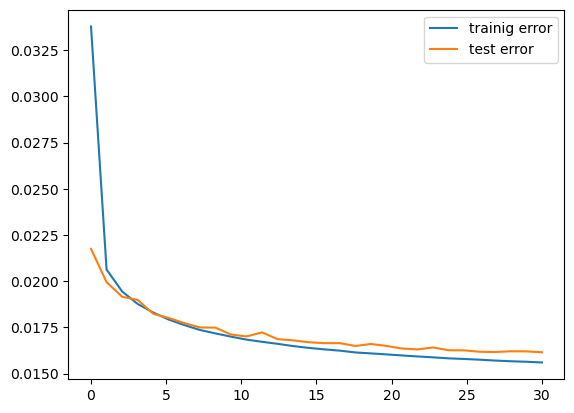

In [ ]:
with torch.no_grad():
    X = np.linspace(0,num_of_epoch,30)
    Y0 = np.divide(train_loss , len(train_loader)) 
    Y1 = np.divide(test_loss , len(test_loader))

    plt.plot(X, Y0 , label = 'trainig error')
    plt.plot(X, Y1 , label = 'test error')
    plt.legend()
    plt.show()

Loading model 

In [ ]:
model = AutoEncoder()
model.load_state_dict(torch.load('./Models/AutoEncoder10.wght'))


C:\Users\rezam\AppData\Local\Temp\ipykernel_19384\492780393.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('./Models/AutoEncoder10.wght

<All keys matched successfully>

Model Evaluation on Test Dataset

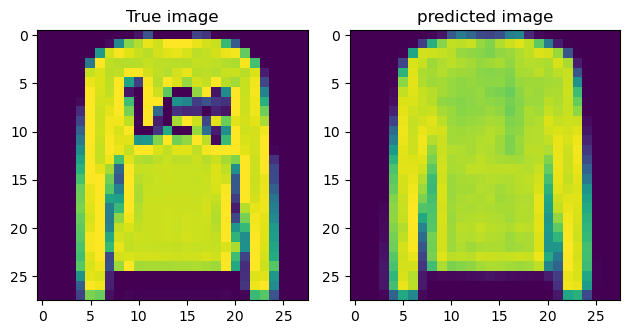

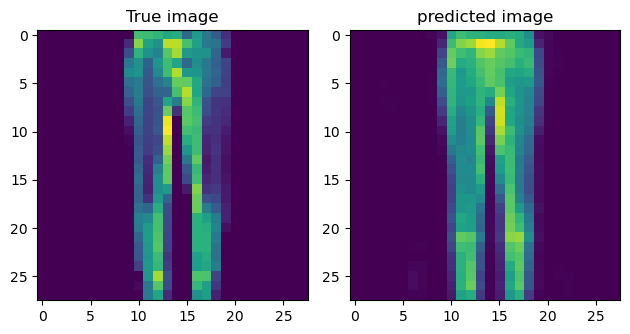

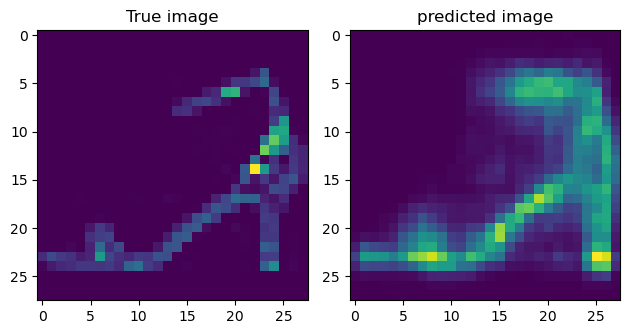

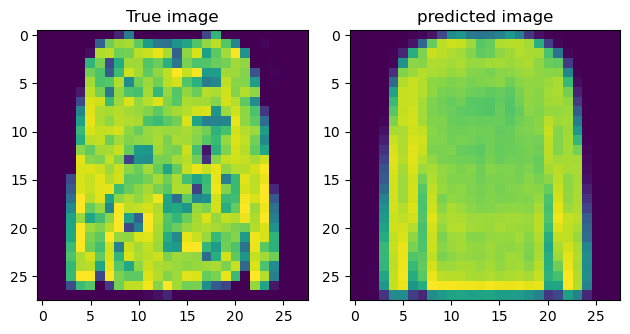

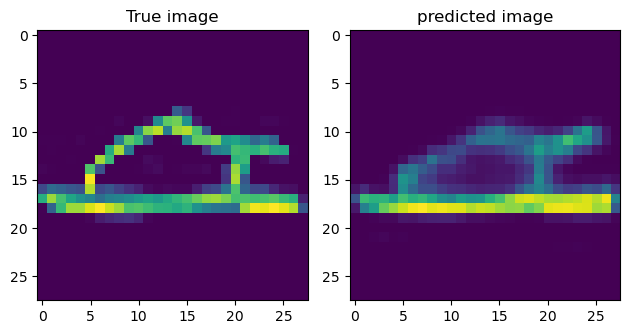

tensor(2.3064)


In [8]:
with torch.no_grad():
    test = iter(test_loader)
    LOSS = 0
    for i , (images , lables) in enumerate(test):
        flattened = images.view(images.size(0), -1)
        outputs=model(flattened)
        if i <5:
            plt.subplot(1,2,1)
            plt.imshow(images[1][0]*255 )
            plt.title("True image")
            restore = outputs.view(original_shape)
            plt.subplot(1,2,2)
            plt.imshow(restore[1][0]*255)
            plt.title("predicted image")

            plt.tight_layout()
            plt.show()
        LOSS +=loss(outputs , flattened)
    print(LOSS)
        

Encoding test datas

In [9]:
with torch.no_grad():
    test = iter(test_loader)
    Encoded_data = []
    labels_list = []
    test_data = []
    for (images , labels) in test:
        flattened = images.view(images.size(0), -1)
        encode=model.Encode(flattened)
        Encoded_data.append(encode)
        labels_list.append(labels)
        test_data.append(flattened)
    
    Encoded_data = torch.cat(Encoded_data ,dim=0)
    y_true = torch.cat(labels_list ,dim=0)
    test_data = torch.cat(test_data ,dim=0)


Set K-means algorithm

In [10]:
kmeans = KMeans(n_clusters=10 , random_state=0)
y_pred = kmeans.fit_predict(Encoded_data)


Finding true labels

In [11]:
mapping ={}
for cluster in range(10):
    mask = (y_pred == cluster)
    most_common = mode(y_true[mask], keepdims = True)[0][0]
    mapping[cluster] = most_common

y_mapped = [mapping[c] for c in y_pred]


At this stage , we can create the Confusion matrix

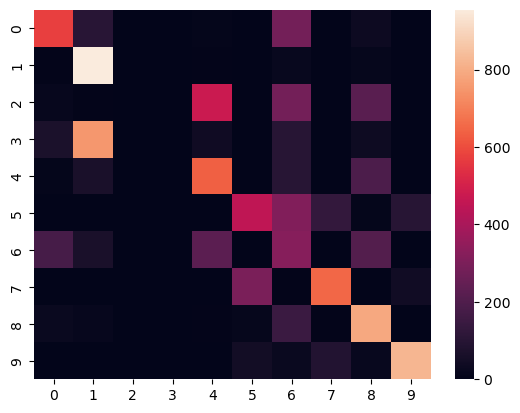

In [12]:
cm =confusion_matrix(y_true , y_mapped)
sb.heatmap(cm)
plt.show()

Dimension reduction with T_SNE

In [13]:
tsne = TSNE(n_components=2 , random_state=0)
X_2d = tsne.fit_transform(Encoded_data)
print(X_2d.shape)

(10000, 2)


Plotting the results

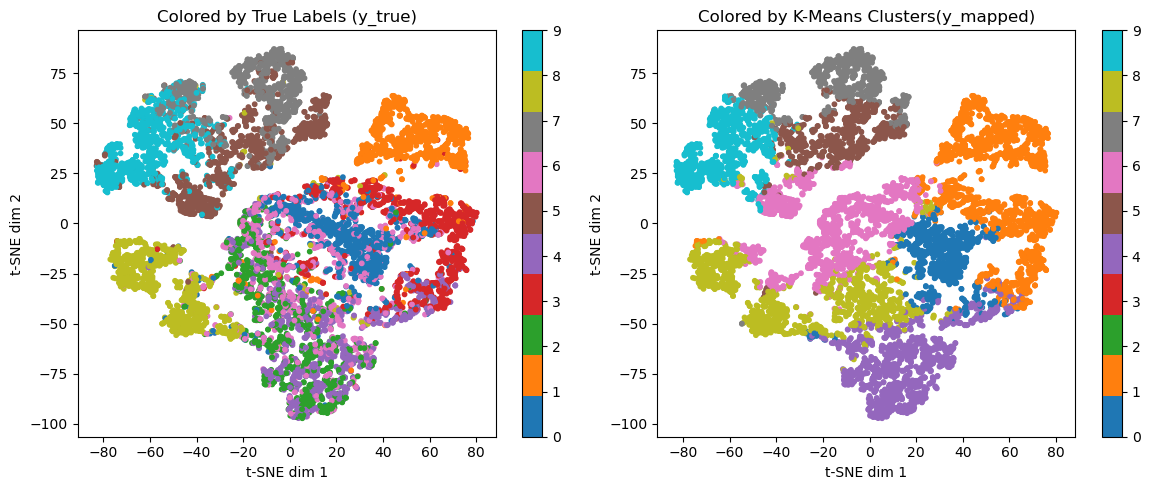

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap='tab10', s=10)
axes[0].set_title("Colored by True Labels (y_true)")
axes[0].set_xlabel("t-SNE dim 1")
axes[0].set_ylabel("t-SNE dim 2")
fig.colorbar(sc1, ax=axes[0])


sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_mapped, cmap='tab10', s=10)
axes[1].set_title("Colored by K-Means Clusters(y_mapped)")
axes[1].set_xlabel("t-SNE dim 1")
axes[1].set_ylabel("t-SNE dim 2")
fig.colorbar(sc2, ax=axes[1])

plt.tight_layout()
plt.show()

Now we use test data in original dimension for K-Means and T-SNE steps

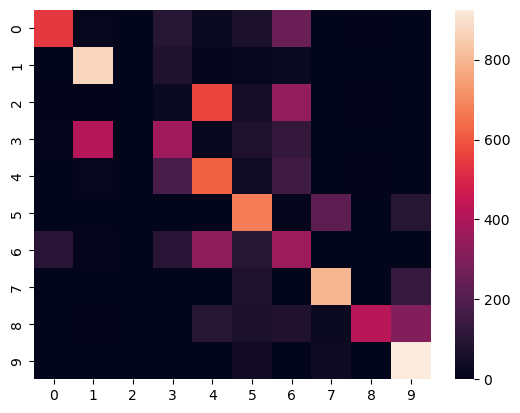

In [15]:
y_pred = kmeans.fit_predict(test_data)

mapping ={}
for cluster in range(10):
    mask = (y_pred == cluster)
    most_common = mode(y_true[mask], keepdims = True)[0][0]
    mapping[cluster] = most_common

y_mapped1 = [mapping[c] for c in y_pred]

cm =confusion_matrix(y_true , y_mapped1)
sb.heatmap(cm)
plt.show()


In [16]:
X_2d =tsne.fit_transform(test_data)
print(X_2d.shape)

(10000, 2)


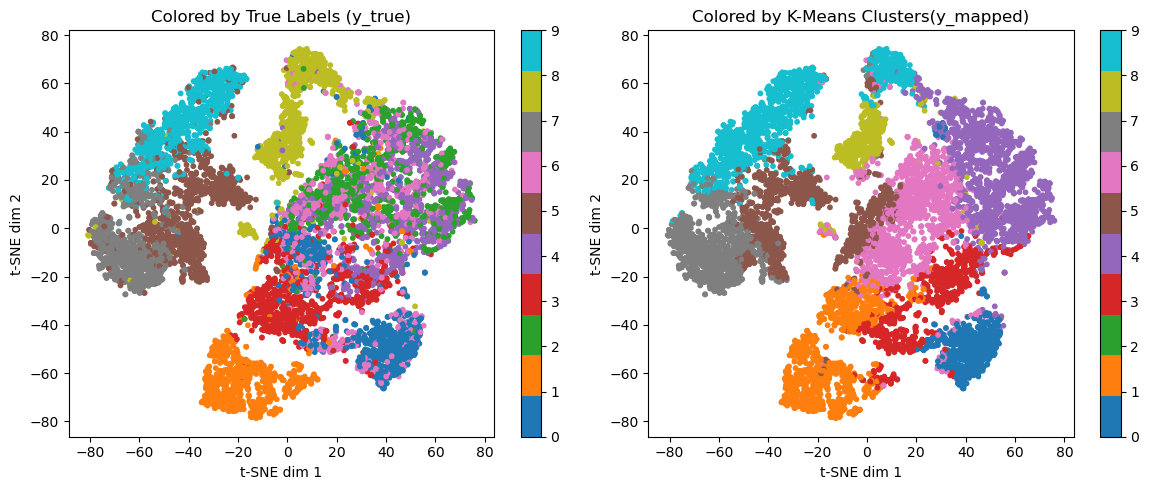

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap='tab10', s=10)
axes[0].set_title("Colored by True Labels (y_true)")
axes[0].set_xlabel("t-SNE dim 1")
axes[0].set_ylabel("t-SNE dim 2")
fig.colorbar(sc1, ax=axes[0])


sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_mapped1, cmap='tab10', s=10)
axes[1].set_title("Colored by K-Means Clusters(y_mapped)")
axes[1].set_xlabel("t-SNE dim 1")
axes[1].set_ylabel("t-SNE dim 2")
fig.colorbar(sc2, ax=axes[1])

plt.tight_layout()
plt.show()

Adjusted Rand Index

In [27]:
def adj_rand_index(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    labels_true, true_idx = np.unique(y_true, return_inverse=True)
    labels_pred, pred_idx = np.unique(y_pred, return_inverse=True)
    
    n_classes = len(labels_true)
    n_clusters = len(labels_pred)
    n_samples = len(y_true)
    
    cont = np.zeros((n_classes, n_clusters), dtype=int)
    for i in range(n_samples):
        cont[true_idx[i], pred_idx[i]] += 1
    
    sum_comb_c = sum(comb(x, 2) for x in cont.flatten())
    sum_comb_r = sum(comb(np.sum(r), 2) for r in cont)
    sum_comb_c_col = sum(comb(np.sum(c), 2) for c in cont.T)
    total_pairs = comb(n_samples, 2)
    
    expected = (sum_comb_r * sum_comb_c_col) / total_pairs
    max_idx = 0.5 * (sum_comb_r + sum_comb_c_col)
    
    return (sum_comb_c - expected) / (max_idx - expected)


In [ ]:
ARI = adj_rand_index(y_true , y_mapped)
print(f"ARI for Encoded test dataset {ARI:.3f}")
ARI1 = adj_rand_index(y_true ,y_mapped1)
print(f"ARI for raw test dataset {ARI1:.3f}")


ARI for Encoded test dataset 0.357
ARI for raw test dataset 0.370


Adjusted Mutual Information without calculating EMI

In [26]:
def cont_matrix(y1, y2):
    y1, y2 = np.asarray(y1), np.asarray(y2)
    if len(y1) != len(y2):
        raise ValueError("Lengths differ")
    n = len(y1)
    idx1 = {v: i for i, v in enumerate(np.unique(y1))}
    idx2 = {v: j for j, v in enumerate(np.unique(y2))}
    r, c = len(idx1), len(idx2)
    M = np.zeros((r, c), dtype=np.int64)
    for a, b in zip(y1, y2):
        M[idx1[a], idx2[b]] += 1
    A = M.sum(axis=1)
    B = M.sum(axis=0)
    return M, A, B, n

def ent(cnt):
    N = cnt.sum()
    p = cnt[cnt > 0] / N
    return -np.sum(p * np.log(p))

def mi_from_mat(M, A, B, n):
    s = 0
    r, c = M.nonzero()
    for i, j in zip(r, c):
        nij = M[i, j]
        if nij > 0:
            s += (nij / n) * math.log((n * nij) / (A[i] * B[j]))
    return s

def adj_mi(y1, y2, avg="arith"):
    y1, y2 = np.asarray(y1), np.asarray(y2)
    if len(y1) != len(y2):
        raise ValueError("Lengths differ")
    if np.array_equal(y1, y2):
        return 1.0

    M, A, B, n = cont_matrix(y1, y2)
    Hu, Hv = ent(A), ent(B)
    MI = mi_from_mat(M, A, B, n)

    EMI = 0.0  

    if avg == "min":
        norm = min(Hu, Hv)
    elif avg == "geo":
        norm = math.sqrt(Hu * Hv)
    elif avg == "arith":
        norm = (Hu + Hv) / 2
    elif avg == "max":
        norm = max(Hu, Hv)
    else:
        raise ValueError("invalid avg method")

    den = norm - EMI
    num = MI - EMI
    if den <= 1e-12:
        return 0.0
    res = num / den
    return max(-1.0, min(1.0, res))

In [ ]:
AMI = adj_mi(y_true , y_mapped)
print(f"AMI for Encoded test dataset {AMI:.3f}")
AMI1 = adj_mi(y_true ,y_mapped1)
print(f"AMI for raw test dataset {AMI1:.3f}")


ARI for Encoded test dataset 0.502
ARI for raw test dataset 0.510
